In [1]:
#Install and import
!pip install yfinance hmmlearn pandas numpy matplotlib seaborn

import yfinance as yf
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

## Download the necessary data.

In [3]:
vix = yf.download("^VIX", start="2000-01-01", auto_adjust="True")
spy = yf.download("SPY", start="2000-01-01", auto_adjust="True")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Grab the necessary columns, clean, and calculate our log returns for SPY

In [5]:
spy_close = spy["Close"].dropna()
vix_close = vix["Close"].dropna()

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()

## Data Overview

### SPY Log Returns (2000–Present)
- **Mean**: 0.0003 — small positive drift, reflects long-term upward trend
- **Std**: 0.012 — ~1.2% average daily volatility
- **Min**: -0.116 — worst single day crash (likely March 2020 or Oct 2008)
- **Max**: 0.136 — largest single day gain (likely post-crash recovery)

### VIX (2000–Present)
- **Mean**: 19.8 — historically anything below 20 is considered calm
- **Min**: 9.14 — extremely low fear, deep bull market conditions
- **Max**: 82.69 — COVID March 2020, peak panic
- **75th percentile**: 23.2 — 75% of days VIX was below 23, so above this is elevated fear

In [7]:
print(log_returns.describe())
print()
print(vix_close.describe())

Ticker          SPY
count   6631.000000
mean       0.000315
std        0.012178
min       -0.115886
25%       -0.004593
50%        0.000692
75%        0.005977
max        0.135577

Ticker         ^VIX
count   6632.000000
mean      19.840201
std        8.321141
min        9.140000
25%       14.020000
50%       17.830000
75%       23.219999
max       82.690002


## Plotting SPY & VIX Closing Prices

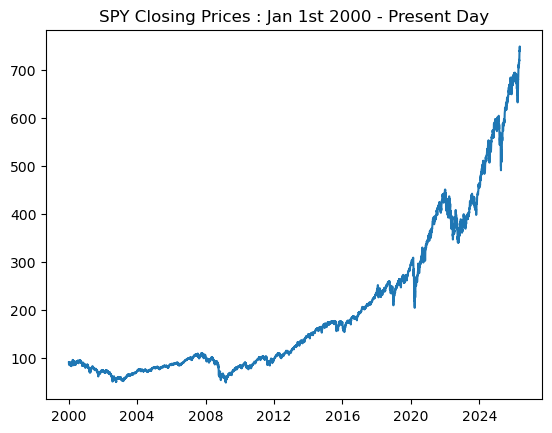

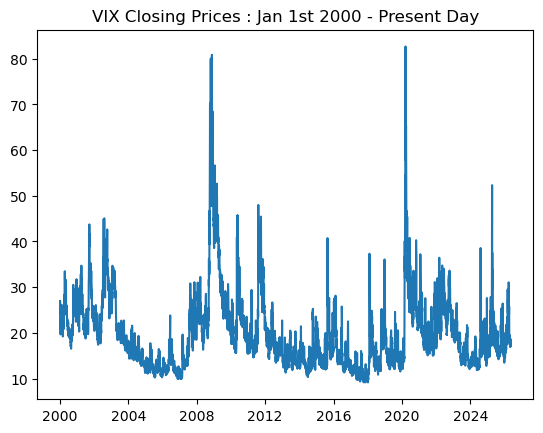

In [9]:
plt.plot(spy_close)
plt.title('SPY Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

plt.plot(vix_close)
plt.title('VIX Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

## Create / Clean the Data Frame

In [11]:
df = pd.concat([log_returns, vix_close], axis=1)
df_cleaned = df.dropna()
df_cleaned.shape

(6631, 2)

## Normalizing Values

Because the values of VIX are much higher than the ones in SPY, here we standardize the values to be centered around a mean of 0 and a standard deviation of 1

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
print(df_scaled)

[[-3.30183705  0.8617337 ]
 [ 0.12089372  0.78962666]
 [-1.35638249  0.70790537]
 ...
 [ 0.43228246 -0.2366961 ]
 [ 0.61984711 -0.31000495]
 [-1.01974292 -0.1693963 ]]


In [14]:
from hmmlearn import hmm
import collections

model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)

model.fit(df_scaled)
states = model.predict(df_scaled)

print(states)
print(collections.Counter(states))
print(model.means_)

[2 2 2 ... 0 0 0]
Counter({0: 2679, 1: 2351, 2: 1601})
[[ 0.00948149 -0.09535246]
 [ 0.05889327 -0.80987463]
 [-0.10164821  1.33867129]]


(6631, 1)
['red', 'red', 'red', 'red', 'green']


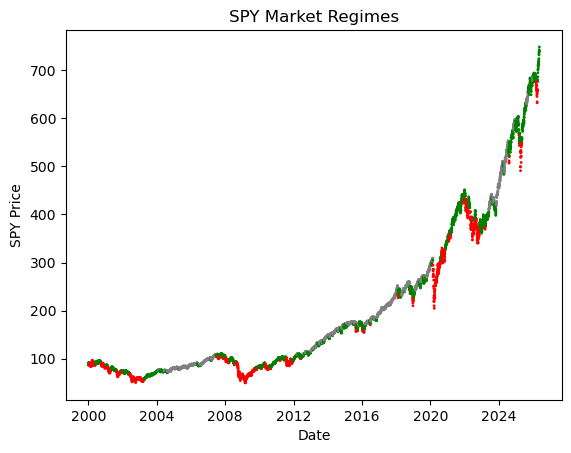

Ticker,SPY,^VIX
Date,,
2000-01-04,-0.039892,27.010000
2000-01-05,0.001787,26.410000
2000-01-06,-0.016202,25.730000
2000-01-07,0.056452,21.719999
2000-01-10,0.003425,21.709999
...,...,...
2026-05-11,0.002275,18.379999
2026-05-12,-0.001516,17.990000
2026-05-13,0.005579,17.870001


In [15]:
spy_aligned = spy_close.loc[df_cleaned.index]
print(spy_aligned.shape)

colors = [{0: "green", 1: "gray", 2: "red"}[s] for s in states]
print(colors[:5])

plt.scatter(df_cleaned.index, spy_aligned, c=colors, s=1)
plt.title("SPY Market Regimes")
plt.xlabel("Date")
plt.ylabel("SPY Price")
plt.show()

df_cleaned

# Feature Engineering

Discretized Log returns: [-∞, -0.0046, 0.0060, ∞]

Decretized VIX: [-∞, 14.01, 23.20, ∞]

Labels: ['low', 'medium', 'high']

dataframe with these five columns — log_return, vix, regime, return_bin, vix_bin.

In [17]:
log_return = df_cleaned['SPY']
vix = df_cleaned['^VIX']
regime = pd.Categorical.from_codes(states, categories=["bull", "sideways", "bear"])
return_bin = pd.cut(df_cleaned['SPY'], bins=[-np.inf, -0.0046, 0.0060, np.inf], labels=["low", "medium", "high"])
vix_bin = pd.cut(df_cleaned['^VIX'], bins=[-np.inf, 14.01, 23.20, np.inf], labels=["low", "neutral", "high"])

df_q_info = pd.DataFrame({
    'log_return': log_return,
    'volatility' : vix,
    'regime': regime,
    'return_disc': return_bin,
    'volatility_disc': vix_bin,
    'spy_close': spy_aligned.squeeze(),
    # market momentum
})

df_q_info

,log_return,volatility,regime,return_disc,volatility_disc,spy_close
Date,,,,,,
2000-01-04,-0.039892,27.010000,bear,low,high,87.794487
2000-01-05,0.001787,26.410000,bear,medium,high,87.951553
2000-01-06,-0.016202,25.730000,bear,low,high,86.538078
2000-01-07,0.056452,21.719999,bear,high,neutral,91.563828
2000-01-10,0.003425,21.709999,bull,medium,neutral,91.877998
...,...,...,...,...,...,...
2026-05-11,0.002275,18.379999,bull,medium,neutral,739.299988
2026-05-12,-0.001516,17.990000,bull,medium,neutral,738.179993
2026-05-13,0.005579,17.870001,bull,medium,neutral,742.309998


In this chunk of code, I'm initializing my q table. It'll store the rewards I can gain from taking a specific action from each state to end up in another.

In [19]:
# hyperparameters
n_episodes = 1000 
alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
transaction_cost = 0.001 

In [20]:
q_table = {}
regimes = ["bull", "sideways", "bear"]
return_bins = ["low", "medium", "high"]
vix_bins = ["low", "neutral", "high"]
actions = ['buy', 'sell', 'hold']

for r in regimes:
    for rb in return_bins:
        for vb in vix_bins:
            state = (r, rb, vb)
            q_table[state] = {'buy': 0.0, 'sell': 0.0, 'hold': 0.0} 

{('bull', 'low', 'low'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'low', 'neutral'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'low', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'medium', 'low'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'medium', 'neutral'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'medium', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'high', 'low'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'high', 'neutral'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('bull', 'high', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'low', 'low'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'low', 'neutral'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'low', 'high'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'medium', 'low'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'medium', 'neutral'): {'buy': 0.0, 'sell': 0.0, 'hold': 0.0},
 ('sideways', 'medium', 'hig

In [21]:
episode_rewards = []
episode_trades = []

# training loop
for episode in range(n_episodes):
    money = 10000  
    num_shares = 0
    total_reward = 0
    num_trades = 0
    
    for i, row in enumerate(df_q_info.itertuples(index=False)):
        current_state = (row.regime, row.return_disc, row.volatility_disc)
        current_stock_price = row.spy_close
        before_portfolio_value = (num_shares * current_stock_price) + money
        
        # e-greedy action selection
        if random.random() < epsilon:
            next_action = random.choice(actions)
        else:
            next_action = actions[np.argmax(q_table[current_state])]
        
        position_changed = False
        
        # execute action
        if next_action == 'buy' and money > current_stock_price:
            shares_to_buy = math.floor(money / current_stock_price)
            purchase_cost = current_stock_price * shares_to_buy
            transaction_fee = purchase_cost * transaction_cost
            
            money -= purchase_cost
            money -= transaction_fee
            num_shares += shares_to_buy
            
            if shares_to_buy > 0:
                position_changed = True
                num_trades += 1
                
        elif next_action == 'sell' and num_shares > 0:
            sale_proceeds = num_shares * current_stock_price
            transaction_fee = sale_proceeds * transaction_cost
            
            money += sale_proceeds 
            money -= transaction_fee    
            num_shares = 0
            position_changed = True
            num_trades += 1
        
        # calculate reward
        if i + 1 < len(df_q_info):
            next_row = df_q_info.iloc[i + 1]
            next_stock_price = next_row.spy_close
            after_portfolio_value = (num_shares * next_stock_price) + money
            
            portfolio_return = (after_portfolio_value - before_portfolio_value) / before_portfolio_value

            reward = portfolio_return
            total_reward += reward
            
            next_state = (next_row.regime, next_row.return_disc, next_row.volatility_disc)
            
            # q-learning update
            current_q = q_table[current_state][next_action]
            max_next_q = max(q_table[next_state].values())
            new_q = current_q + alpha * (reward + gamma * max_next_q - current_q)
            q_table[current_state][next_action] = new_q
    
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    final_portfolio = (num_shares * df_q_info.iloc[-1].spy_close) + money
    episode_rewards.append(total_reward)
    episode_trades.append(num_trades)
    
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode + 1}/{n_episodes} | Avg Reward (last 50): {avg_reward:.4f} | Epsilon: {epsilon:.3f} | Trades: {num_trades}")

print("\nTraining complete!")
print(f"Final epsilon: {epsilon:.3f}")
print(f"Average reward: {np.mean(episode_rewards):.4f}")

Episode 50/1000 | Avg Reward (last 50): -0.8066 | Epsilon: 0.778 | Trades: 2265
Episode 100/1000 | Avg Reward (last 50): -0.3011 | Epsilon: 0.606 | Trades: 2018
Episode 150/1000 | Avg Reward (last 50): 0.1030 | Epsilon: 0.471 | Trades: 1675
Episode 200/1000 | Avg Reward (last 50): 0.6467 | Epsilon: 0.367 | Trades: 1394
Episode 250/1000 | Avg Reward (last 50): 1.0854 | Epsilon: 0.286 | Trades: 1148
Episode 300/1000 | Avg Reward (last 50): 1.3306 | Epsilon: 0.222 | Trades: 920
Episode 350/1000 | Avg Reward (last 50): 1.6320 | Epsilon: 0.173 | Trades: 755
Episode 400/1000 | Avg Reward (last 50): 1.8169 | Epsilon: 0.135 | Trades: 550
Episode 450/1000 | Avg Reward (last 50): 1.9845 | Epsilon: 0.105 | Trades: 446
Episode 500/1000 | Avg Reward (last 50): 2.1017 | Epsilon: 0.082 | Trades: 340
Episode 550/1000 | Avg Reward (last 50): 2.2203 | Epsilon: 0.063 | Trades: 274
Episode 600/1000 | Avg Reward (last 50): 2.2979 | Epsilon: 0.049 | Trades: 213
Episode 650/1000 | Avg Reward (last 50): 2.372

In [22]:
final_value = money + (num_shares * df_q_info.iloc[-1].spy_close)
print(f"Started with: $10,000") 
print(f"Ended with: ${final_value:.2f}")
print(f"Return: {((final_value - 10000) / 10000) * 100:.2f}%") 

Started with: $10,000
Ended with: $77081.78
Return: 670.82%


### Compare to a Buy & Hold Baseline

In [24]:
# buy-and-hold 
buy_hold_start_price = df_q_info.iloc[0].spy_close
buy_hold_shares = 10000 / buy_hold_start_price
buy_hold_end_price = df_q_info.iloc[-1].spy_close
buy_hold_final_value = buy_hold_shares * buy_hold_end_price
buy_hold_return = (buy_hold_final_value - 10000) / 10000

print(f"\n=== Buy-and-Hold Baseline ===")
print(f"Started with: $10,000")
print(f"Bought {buy_hold_shares:.2f} shares at ${buy_hold_start_price:.2f}")
print(f"Sold at ${buy_hold_end_price:.2f}")
print(f"Ended with: ${buy_hold_final_value:.2f}")
print(f"Return: {buy_hold_return * 100:.2f}%")
print(f"Trades: 2 (buy at start, sell at end)")

print(f"\n=== Q-Learning Agent ===")
print(f"Started with: $10,000")
print(f"Ended with: ${final_value:.2f}")
print(f"Return: {((final_value - 10000) / 10000) * 100:.2f}%")
print(f"Trades: {num_trades}")

print(f"\n=== Comparison ===")
if final_value > buy_hold_final_value:
    outperformance = ((final_value / buy_hold_final_value) - 1) * 100
    print(f"✅ Agent OUTPERFORMED by {outperformance:.2f}%")
else:
    underperformance = (1 - (final_value / buy_hold_final_value)) * 100
    print(f"❌ Agent UNDERPERFORMED by {underperformance:.2f}%")

# Also check date range
print(f"\n=== Data Info ===")
print(f"Start date: {df_q_info.index[0] if hasattr(df_q_info, 'index') else 'N/A'}")
print(f"End date: {df_q_info.index[-1] if hasattr(df_q_info, 'index') else 'N/A'}")
print(f"Total days: {len(df_q_info)}")


=== Buy-and-Hold Baseline ===
Started with: $10,000
Bought 113.90 shares at $87.79
Sold at $739.17
Ended with: $84193.21
Return: 741.93%
Trades: 2 (buy at start, sell at end)

=== Q-Learning Agent ===
Started with: $10,000
Ended with: $77081.78
Return: 670.82%
Trades: 41

=== Comparison ===
❌ Agent UNDERPERFORMED by 8.45%

=== Data Info ===
Start date: 2000-01-04 00:00:00
End date: 2026-05-15 00:00:00
Total days: 6631
